### Ken Vellian
### CSC 578: Neural Networks and Deep Learning
### Due: 03/20/25

### Final Project: Multi-Class Brain Tumor Classification Using CNNs & Explainable AI

### How to run: Run Jupyter Notebook via Google Colab T4 GPU

## Introduction to Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import subprocess


import os
import zipfile
import hashlib
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


# Torchvision Modules
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader

# Sklearn Modules
from sklearn.metrics import confusion_matrix, classification_report

# Skimage for Image Segmentation
from skimage.segmentation import mark_boundaries, slic, felzenszwalb, quickshift

# TensorFlow for Preprocessing
from tensorflow.keras.applications.resnet50 import preprocess_input

# LIME for Model Interpretability
!pip install lime > /dev/null 2>&1
from lime import lime_image
from lime.lime_image import LimeImageExplainer

# Install Kaggle API
!pip install kaggle > /dev/null 2>&1

# Create a hidden directory for Kaggle API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# Change permissions of kaggle.json to prevent issues
!chmod 600 ~/.kaggle/kaggle.json

print("All required libraries installed successfully.")
print("All library imports are successful.")


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
All required libraries installed successfully.
All library imports are successful.


In [2]:
# Use the Kaggle API to download the Brain Tumor MRI dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
100% 149M/149M [00:05<00:00, 31.7MB/s]
100% 149M/149M [00:05<00:00, 27.3MB/s]


In [3]:
# Unzipping the downloaded dataset
with zipfile.ZipFile("brain-tumor-mri-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("brain_tumor_data")  # Extracting all files into the "brain_tumor_data" directory

print("Dataset extracted successfully. Check Contents folder.")

Dataset extracted successfully. Check Contents folder.


## Exploratory Data Analysis

In [4]:
# Defining the dataset path
dataset_path = "brain_tumor_data"

def count_images(folder):
    """
    Counting the number of images in each class within a given dataset folder.

    Parameters
    ----------
    folder : str
        Path to the dataset folder containing different tumor classes.

    Returns
    -------
    class_counts : dict
        Dictionary containing the tumor class names as keys and the number of images as values.

    """
    class_counts = {}  # Initializing an empty dictionary to store class counts

    # Iterating through each class directory in the given folder
    for tumor_class in os.listdir(folder):
        class_path = os.path.join(folder, tumor_class)  # Constructing full class path
        if os.path.isdir(class_path):  # Checking if the path is a valid directory
            class_counts[tumor_class] = len(os.listdir(class_path))  # Counting the number of images in the class

    return class_counts  # Returning the dictionary of image counts per class

# Counting images in the Training and Testing sets
train_counts = count_images(os.path.join(dataset_path, "Training"))
test_counts = count_images(os.path.join(dataset_path, "Testing"))

# Printing results for the Training set
print("Training Set Image Counts:")
for tumor_type, count in train_counts.items():
    print(f"{tumor_type}: {count} images")

# Printing results for the Testing set
print("\nTesting Set Image Counts:")
for tumor_type, count in test_counts.items():
    print(f"{tumor_type}: {count} images")


Training Set Image Counts:
glioma: 1321 images
notumor: 1595 images
pituitary: 1457 images
meningioma: 1339 images

Testing Set Image Counts:
glioma: 300 images
notumor: 405 images
pituitary: 300 images
meningioma: 306 images


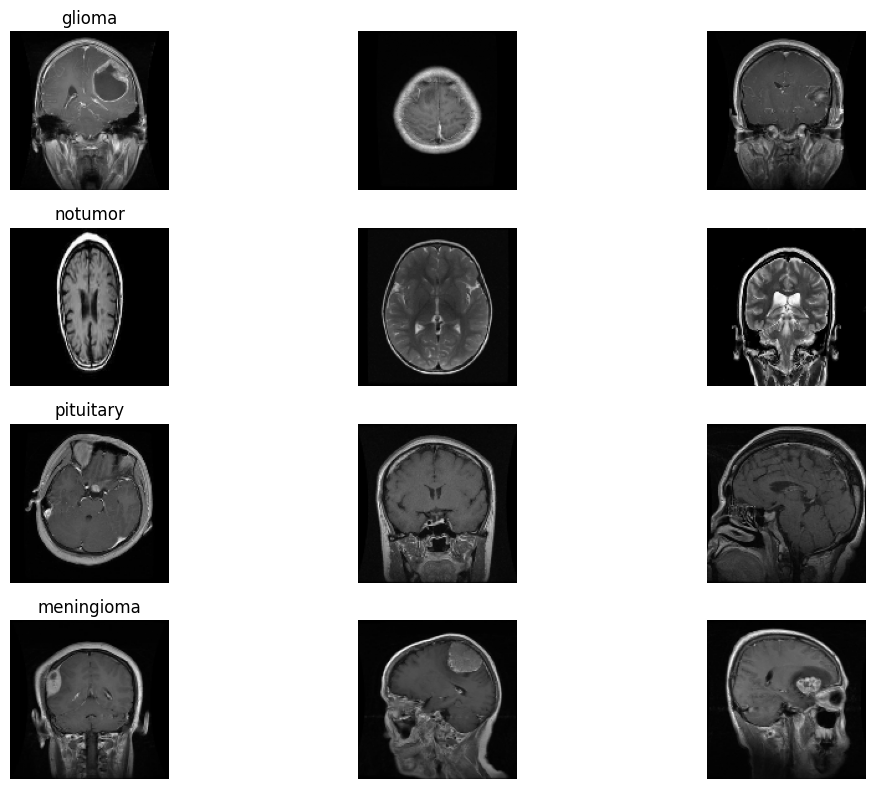

In [5]:
def display_sample_images(dataset_path, subset = "Training", num_samples = 3):
    """
    Displaying sample MRI images from different tumor classes.

    Parameters
    ----------
    dataset_path : str
        Path to the dataset directory containing the images.
    subset : str, optional
        Subdirectory to select images from, default is "Training".
    num_samples : int, optional
        Number of images to display per class, default is 3.

    Returns
    -------
    None
        Displays a matplotlib figure of sample images.

    """

    # Creating a figure with 4 rows (for each tumor class) and `num_samples` columns
    fig, axes = plt.subplots(4, num_samples, figsize = (12, 8))

    # Listing all tumor class folders within the specified dataset subset
    tumor_classes = os.listdir(os.path.join(dataset_path, subset))

    # Iterating through each tumor class
    for i, tumor_class in enumerate(tumor_classes):
        class_path = os.path.join(dataset_path, subset, tumor_class)  # Constructing the class path
        images = os.listdir(class_path)  # Listing all images in the class directory
        sample_images = random.sample(images, num_samples)  # Selecting a random set of images

        # Iterating through the selected images
        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)  # Constructing full image path
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Reading the image in grayscale mode
            img = cv2.resize(img, (128, 128))  # Resizing the image for visualization

            axes[i, j].imshow(img, cmap = "gray")  # Displaying the image using a grayscale colormap
            axes[i, j].axis("off")  # Hiding axis labels for a cleaner display

            # Setting the title for the first image in each row (class label)
            if j == 0:
                axes[i, j].set_title(tumor_class, fontsize = 12)

    plt.tight_layout()  # Adjusting layout to prevent overlap
    plt.show()  # Displaying the images

# Displaying sample MRI images from the Training set
display_sample_images(dataset_path, subset = "Training", num_samples = 3)


## Checking for class imbalance

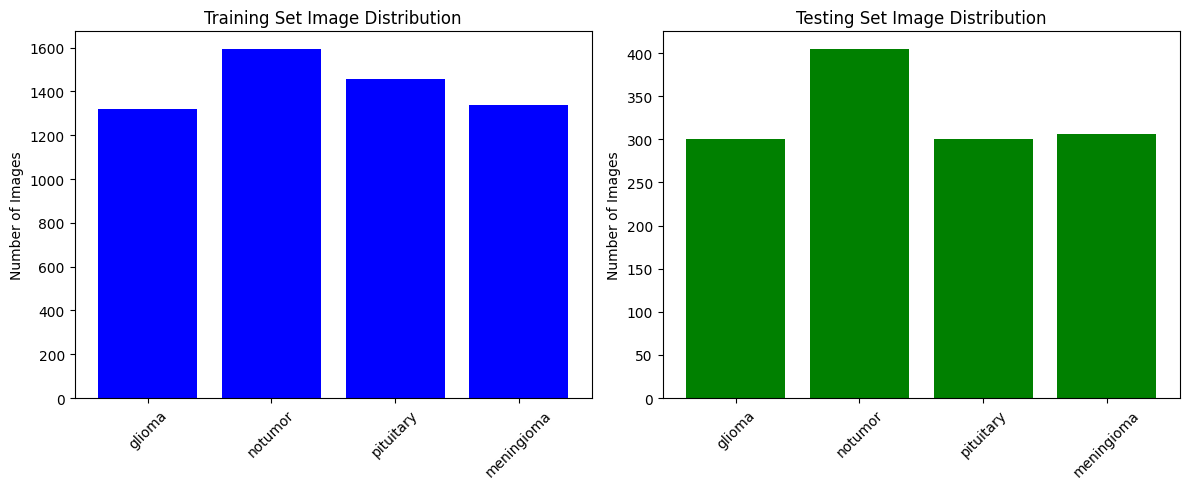

In [6]:
# ----------------------------------------------------------------------------
# Visualization - Bar Plot of Image Counts per Class
# ----------------------------------------------------------------------------

# Creating a figure with two bar plots (one for Training, one for Testing)
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Training Set image distribution
axes[0].bar(train_counts.keys(), train_counts.values(), color = "blue")
axes[0].set_title("Training Set Image Distribution")
axes[0].set_ylabel("Number of Images")
axes[0].set_xticklabels(train_counts.keys(), rotation = 45)

# Plotting Testing Set image distribution
axes[1].bar(test_counts.keys(), test_counts.values(), color = "green")
axes[1].set_title("Testing Set Image Distribution")
axes[1].set_ylabel("Number of Images")
axes[1].set_xticklabels(test_counts.keys(), rotation = 45)

plt.tight_layout()  # Adjusting layout to prevent label overlap
plt.show()  # Displaying the bar plots

In [7]:
# ----------------------------------------------------------------------------
# Defining Dataset Paths
# ----------------------------------------------------------------------------

# Defining the path for the training dataset
TRAIN_DIR = "brain_tumor_data/Training"

# Defining the path for the testing dataset
TEST_DIR = "brain_tumor_data/Testing"

# ----------------------------------------------------------------------------
# MD5 Hashing for Duplicate Detection
# ----------------------------------------------------------------------------

def compute_md5(file_path):
    """
    Computing the MD5 hash of an image file.

    Parameters
    ----------
    file_path : str
        Path to the image file.

    Returns
    -------
    str
        MD5 hash of the file.
    """

    # Creating an MD5 hashing object
    hasher = hashlib.md5()

    # Opening the file in binary read mode
    with open(file_path, 'rb') as f:

        # Reading the entire file content
        buf = f.read()

        # Updating the hasher with the file content
        hasher.update(buf)

    # Returning the computed MD5 hash as a string
    return hasher.hexdigest()

# ----------------------------------------------------------------------------
# Identifying and Removing Duplicate Images
# ----------------------------------------------------------------------------

def find_duplicates(directory):
    """
    Identifying duplicate images within a directory based on MD5 hashes.

    Parameters
    ----------
    directory : str
        Path to the directory containing images.

    Returns
    -------
    list
        List of duplicate file paths.
    """

    # Initializing dictionary to store unique image hashes
    hash_dict = {}

    # Initializing list to store paths of duplicate images
    duplicates = []

    # Walking through all files in the directory (including subdirectories)
    for root, _, files in os.walk(directory):

        # Iterating through each file in the current directory
        for file in files:

            # Processing only image files (JPG, PNG, JPEG)
            if file.endswith(('.jpg', '.png', '.jpeg')):

                # Constructing the full file path
                file_path = os.path.join(root, file)

                # Computing the MD5 hash of the file
                file_hash = compute_md5(file_path)

                # Checking if the file hash already exists
                if file_hash in hash_dict:

                    # Adding the duplicate file path to the list
                    duplicates.append(file_path)

                else:
                    # Storing the unique file hash with its corresponding file path
                    hash_dict[file_hash] = file_path

    # Returning the list of duplicate file paths
    return duplicates

def remove_duplicates(duplicates):
    """
    Deleting duplicate files and printing a summary.

    Parameters
    ----------
    duplicates : list
        List of duplicate file paths.

    Returns
    -------
    None
    """

    # Checking if there are no duplicates
    if not duplicates:
        print("No duplicate images found.")
        return

    # Printing the number of duplicate images found
    print(f"Found {len(duplicates)} duplicate images. Removing them.")

    # Iterating through each duplicate file
    for file in duplicates:

        # Removing the duplicate file
        os.remove(file)

        # Printing confirmation message
        print(f"Removed: {file}")

    # Printing final confirmation after removing all duplicates
    print(f"Successfully removed {len(duplicates)} duplicate images.")

# ----------------------------------------------------------------------------
# Running Duplicate Detection and Removal
# ----------------------------------------------------------------------------

# Printing message indicating the scanning process has started
print("Scanning for duplicate images in the dataset...")

# Checking for duplicate images in the training set
train_duplicates = find_duplicates(TRAIN_DIR)

# Checking for duplicate images in the testing set
test_duplicates = find_duplicates(TEST_DIR)

# Removing duplicate images from the training set
remove_duplicates(train_duplicates)

# Removing duplicate images from the testing set
remove_duplicates(test_duplicates)

# Printing message indicating the duplicate removal process is complete
print("Duplicate removal process completed!")


Scanning for duplicate images in the dataset...
Found 191 duplicate images. Removing them.
Removed: brain_tumor_data/Training/notumor/Tr-no_0117.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0236.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0341.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_1183.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0013.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_1059.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0982.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0220.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0142.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_1178.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0373.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_1129.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_0394.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_1114.jpg
Removed: brain_tumor_data/Training/notumor/Tr-no_1179.jpg
Removed: brain_tumor_data/Training/notu

In [8]:
# ----------------------------------------------------------------------------
# Counting images in Training and Testing sets
# ----------------------------------------------------------------------------

# Counting the number of images in each class within the Training dataset
train_counts = count_images(os.path.join(dataset_path, "Training"))

# Counting the number of images in each class within the Testing dataset
test_counts = count_images(os.path.join(dataset_path, "Testing"))

# Printing the count of images per class in the Training dataset
print("Training Set Image Counts:")
for tumor_type, count in train_counts.items():
    print(f"{tumor_type}: {count} images")  # Displaying tumor type and image count

# Printing the count of images per class in the Testing dataset
print("\nTesting Set Image Counts:")
for tumor_type, count in test_counts.items():
    print(f"{tumor_type}: {count} images")  # Displaying tumor type and image count


Training Set Image Counts:
glioma: 1321 images
notumor: 1422 images
pituitary: 1445 images
meningioma: 1333 images

Testing Set Image Counts:
glioma: 299 images
notumor: 381 images
pituitary: 300 images
meningioma: 304 images


## Model Design and Implementation

## Data Preprocessing and Augmentation

Prepare the images before applying them into ResNet50.

Next steps:

**Resizing**: Convert images to 224x224 pixels for ResNet50’s input size requirement.

**Normalization**: Scale pixel values between 0 and 1 (or standardize using ImageNet means).

**Data Augmentation** (for training only):

*     Random Horizontal Flip (simulating different orientations)
*     Random Rotation (making model robust to orientation)
*     Color Jittering (adjusting brightness, contrast, saturation)
*     Affine Transformations (shift, scale, shear images)


In [9]:
# https://pytorch.org/vision/stable/models.html
# https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2

In [10]:
# ----------------------------------------------------------------------------
# Defining Image Transformations for Training and Testing Datasets
# ----------------------------------------------------------------------------

# Applying transformations to the training dataset, including augmentations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resizing all images to 224x224 (required input size for ResNet50)
    transforms.RandomHorizontalFlip(),  # Randomly flipping images horizontally (increases data diversity)
    transforms.RandomRotation(10),  # Rotating images randomly by up to 10 degrees (improves model robustness)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Adjusting brightness, contrast, and saturation (enhances generalization)
    transforms.ToTensor(),  # Converting images to PyTorch tensors (needed for model training)
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normalizing using ImageNet mean & std values (ResNet50 was trained with these stats)
])

# Applying transformations to the testing dataset (no augmentation, only resizing & normalization)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resizing images to 224x224 (matching ResNet50 input size)
    transforms.ToTensor(),  # Converting images to PyTorch tensors
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Applying same normalization as training data
])

# ----------------------------------------------------------------------------
# Loading Datasets and Applying Defined Transformations
# ----------------------------------------------------------------------------

# Pointing to training and testing image directories
train_dataset_path = os.path.join(dataset_path, "Training")  # Training images directory
test_dataset_path = os.path.join(dataset_path, "Testing")  # Testing images directory

# Loading the training dataset and applying the defined transformations
train_dataset = datasets.ImageFolder(root = train_dataset_path, transform = train_transforms)

# Loading the testing dataset and applying the defined transformations
test_dataset = datasets.ImageFolder(root = test_dataset_path, transform = test_transforms)

# ----------------------------------------------------------------------------
# Creating DataLoaders for Efficient Batch Processing
# ----------------------------------------------------------------------------

# Creating a DataLoader for the training dataset (shuffle = True for randomness in batches)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

# Creating a DataLoader for the testing dataset (shuffle = False to maintain order)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

# ----------------------------------------------------------------------------
# Displaying Dataset Statistics
# ----------------------------------------------------------------------------

# Printing the total number of images in the training dataset
print(f"Training images: {len(train_dataset)}")

# Printing the total number of images in the testing dataset
print(f"Testing images: {len(test_dataset)}")


Training images: 5521
Testing images: 1284


## Training Process

## Model Setup & Transfer Learning

Next steps:


*   Loading  ResNet50 with the pretrained weights.

*   Modifying the fully connected layers for the classification.
*   Setting up training configurations (optimizer, loss function, and evaluation metrics).




In [11]:
# ----------------------------------------------------------------------------
# Setting Up the Model for Brain Tumor Classification
# ----------------------------------------------------------------------------

# Setting the device for computation (uses GPU if available, otherwise CPU)
hardware_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {hardware_device}")  # Outputs "cuda" if GPU is available, otherwise "cpu"

# ----------------------------------------------------------------------------
# Defining Tumor Classification Labels
# ----------------------------------------------------------------------------

# Listing the four tumor classification labels
tumor_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Counting the number of tumor classes
num_tumor_classes = len(tumor_labels)  # We have 4 classes

# ----------------------------------------------------------------------------
# Loading ResNet50 Model with Pretrained Weights
# ----------------------------------------------------------------------------

# Loading the ResNet50 model, pretrained on ImageNet dataset
brain_mri_model = models.resnet50(weights = ResNet50_Weights.IMAGENET1K_V1)

# ----------------------------------------------------------------------------
# Freezing Initial Convolutional Layers Except Last Block (`layer4`)
# ----------------------------------------------------------------------------

# Iterating through all parameters and freezing them (no gradient updates)
for param in brain_mri_model.parameters():
    param.requires_grad = False  # Freezing all feature extractor layers

# Unfreezing the last convolutional block (`layer4`) for fine-tuning
for param in brain_mri_model.layer4.parameters():
    param.requires_grad = True  # Allowing updates to these layers

# ----------------------------------------------------------------------------
# Modifying the Final Fully Connected Layer for Brain Tumor Classification
# ----------------------------------------------------------------------------

# Extracting the number of input features from the original ResNet50 FC layer
num_input_features = brain_mri_model.fc.in_features

# Replacing the fully connected (fc) layer to match our classification task
brain_mri_model.fc = nn.Sequential(
    nn.Linear(num_input_features, 256),  # Adding a dense layer with 256 neurons
    nn.ReLU(),  # Applying ReLU activation for non-linearity
    nn.Dropout(0.4),  # Adding dropout (40%) to prevent overfitting
    nn.Linear(256, num_tumor_classes)  # Final output layer with 4 neurons (one per tumor class)
)

# ----------------------------------------------------------------------------
# Moving the Model to the Appropriate Device (GPU or CPU)
# ----------------------------------------------------------------------------

# Transferring the model to the selected hardware device
brain_mri_model = brain_mri_model.to(hardware_device)

# ----------------------------------------------------------------------------
# Defining Loss Function for Multi-Class Classification
# ----------------------------------------------------------------------------

# Using CrossEntropyLoss, since this is a multi-class classification problem
classification_loss_fn = nn.CrossEntropyLoss()

# ----------------------------------------------------------------------------
# Configuring Optimizer for Fine-Tuning
# ----------------------------------------------------------------------------

# Using Adam optimizer with different learning rates for different layers
fine_tune_optimizer = torch.optim.Adam([
    {'params': brain_mri_model.layer4.parameters(), 'lr': 1e-5},  # Lower LR for fine-tuning deeper layers
    {'params': brain_mri_model.fc.parameters(), 'lr': 1e-4}  # Higher LR for training new FC layers
], weight_decay = 1e-4)  # Adding weight decay for regularization

# ----------------------------------------------------------------------------
# Setting Up Learning Rate Scheduler for Dynamic Adjustments
# ----------------------------------------------------------------------------

# Using StepLR to reduce learning rate every 10 epochs by a factor of 0.1
lr_scheduler = torch.optim.lr_scheduler.StepLR(fine_tune_optimizer, step_size = 10, gamma = 0.1)

# ----------------------------------------------------------------------------
# Final Model Setup Message
# ----------------------------------------------------------------------------

print("Brain MRI ResNet50 Model is Ready for Training")


Running on: cuda


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Brain MRI ResNet50 Model is Ready for Training


## Training the Model

Next steps:


*   Defining the Training Loop
*   Monitoring Accuracy and Loss
*   Training for 16 Epochs with Early Stopping based on research from Saeedi et al. (2023).
*   Creating Learning Rate Scheduler so the learning rate is adjusted dynamically.
*   Plotting Accuracy and Loss Curves to visualize performance.



In [12]:
# ----------------------------------------------------------------------------
# Implementing Custom Early Stopping for Training Optimization
# ----------------------------------------------------------------------------

class CustomStopper:
    """
    Custom early stopping mechanism to halt training when validation loss
    fails to improve over a specified number of epochs.

    Parameters
    ----------
    wait_epochs : int
        Number of consecutive epochs without significant improvement before stopping.
    min_improvement : float
        Minimum required decrease in validation loss to reset the counter.

    Attributes
    ----------
    no_progress_count : int
        Counts epochs without sufficient improvement.
    best_recorded_loss : float or None
        Tracks the lowest validation loss observed.
    stop_training : bool
        Indicates whether training should stop.
    """

    def __init__(self, wait_epochs = 3, min_improvement = 0.001):
        self.wait_epochs = wait_epochs  # Number of epochs to wait before stopping
        self.min_improvement = min_improvement  # Minimum required improvement
        self.no_progress_count = 0  # Counter for non-improving epochs
        self.best_recorded_loss = None  # Stores the best validation loss seen
        self.stop_training = False  # Flag to indicate stopping condition

    def __call__(self, val_loss):
        """
        Checks whether validation loss has improved and determines if training should stop.

        Parameters
        ----------
        val_loss : float
            Current validation loss.

        Returns
        -------
        None
        """
        if self.best_recorded_loss is None:
            self.best_recorded_loss = val_loss  # Initialize with first validation loss
        elif val_loss > self.best_recorded_loss - self.min_improvement:
            self.no_progress_count += 1  # Increase count if no significant improvement
            if self.no_progress_count >= self.wait_epochs:
                print("Training Stopped: No Significant Improvement!")
                self.stop_training = True  # Set stopping flag
        else:
            self.best_recorded_loss = val_loss  # Update best loss
            self.no_progress_count = 0  # Reset counter if improvement occurs


# ----------------------------------------------------------------------------
# Initializing Early Stopping & Training Parameters
# ----------------------------------------------------------------------------

# Initializing the early stopping mechanism
early_stopper = CustomStopper(wait_epochs = 3, min_improvement = 0.001)

# Defining the total number of training epochs
total_epochs = 16

# Initializing lists to track training & validation performance
train_loss_history = []
valid_loss_history = []
train_acc_history = []
valid_acc_history = []

# ----------------------------------------------------------------------------
# Training Loop for Fine-Tuning ResNet50 Model
# ----------------------------------------------------------------------------

for cycle in range(total_epochs):
    brain_mri_model.train()  # Setting the model to training mode
    batch_train_loss = 0.0  # Accumulating training loss per epoch
    correct_train_preds = 0  # Counting correctly predicted samples
    total_train_samples = 0  # Counting total samples seen

    print(f"\nCycle {cycle + 1}/{total_epochs} - Training Phase")

    for batch_features, batch_labels in tqdm(train_loader, desc = f"Training Cycle {cycle + 1}/{total_epochs}"):
        batch_features, batch_labels = batch_features.to(hardware_device), batch_labels.to(hardware_device)

        fine_tune_optimizer.zero_grad()  # Resetting previous gradients
        predictions = brain_mri_model(batch_features)  # Forward pass
        loss_value = classification_loss_fn(predictions, batch_labels)  # Computing loss
        loss_value.backward()  # Performing backpropagation
        fine_tune_optimizer.step()  # Updating model weights

        # Tracking training metrics
        batch_train_loss += loss_value.item()  # Accumulating batch loss
        _, predicted_classes = torch.max(predictions, 1)  # Retrieving predicted class labels
        correct_train_preds += (predicted_classes == batch_labels).sum().item()  # Counting correct predictions
        total_train_samples += batch_labels.size(0)  # Counting total samples

    # Computing average training loss & accuracy
    avg_train_loss = batch_train_loss / len(train_loader)
    avg_train_accuracy = correct_train_preds / total_train_samples * 100
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(avg_train_accuracy)

    # ----------------------------------------------------------------------------
    # Validation Phase
    # ----------------------------------------------------------------------------

    brain_mri_model.eval()  # Setting the model to evaluation mode
    batch_valid_loss = 0.0  # Accumulating validation loss
    correct_valid_preds = 0  # Counting correct validation predictions
    total_valid_samples = 0  # Counting total validation samples

    print(f"\nCycle {cycle + 1}/{total_epochs} - Validation Phase")

    with torch.no_grad():  # Disabling gradient calculations for validation
        for batch_features, batch_labels in tqdm(test_loader, desc = f"Validating Cycle {cycle + 1}/{total_epochs}"):
            batch_features, batch_labels = batch_features.to(hardware_device), batch_labels.to(hardware_device)

            predictions = brain_mri_model(batch_features)  # Forward pass
            loss_value = classification_loss_fn(predictions, batch_labels)  # Computing validation loss

            # Tracking validation metrics
            batch_valid_loss += loss_value.item()  # Accumulating batch loss
            _, predicted_classes = torch.max(predictions, 1)  # Retrieving predicted class labels
            correct_valid_preds += (predicted_classes == batch_labels).sum().item()  # Counting correct predictions
            total_valid_samples += batch_labels.size(0)  # Counting total samples

    # Computing average validation loss & accuracy
    avg_valid_loss = batch_valid_loss / len(test_loader)
    avg_valid_accuracy = correct_valid_preds / total_valid_samples * 100
    valid_loss_history.append(avg_valid_loss)
    valid_acc_history.append(avg_valid_accuracy)

    # ----------------------------------------------------------------------------
    # Logging Training & Validation Results
    # ----------------------------------------------------------------------------

    print(f"Cycle {cycle + 1}/{total_epochs}: Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_accuracy:.2f}% | "
          f"Valid Loss: {avg_valid_loss:.4f}, Valid Acc: {avg_valid_accuracy:.2f}%")

    # ----------------------------------------------------------------------------
    # Adjusting Learning Rate Using Scheduler
    # ----------------------------------------------------------------------------

    lr_scheduler.step()  # Adjusting learning rate at specified intervals

    # ----------------------------------------------------------------------------
    # Checking for Early Stopping
    # ----------------------------------------------------------------------------

    early_stopper(avg_valid_loss)  # Evaluating if training should be stopped

    if early_stopper.stop_training:
        print("Early stopping triggered. Halting training.")
        break  # Exiting the training loop if early stopping condition is met

# ----------------------------------------------------------------------------
# Saving the Trained Model for Future Use
# ----------------------------------------------------------------------------

# Saving the trained model weights to a file
torch.save(brain_mri_model.state_dict(), "custom_resnet50_brain_tumor.pth")

print("Model saved as custom_resnet50_brain_tumor.pth")



Cycle 1/16 - Training Phase


Training Cycle 1/16: 100%|██████████| 173/173 [00:56<00:00,  3.05it/s]



Cycle 1/16 - Validation Phase


Validating Cycle 1/16: 100%|██████████| 41/41 [00:07<00:00,  5.33it/s]


Cycle 1/16: Train Loss: 0.5955, Train Acc: 78.79% | Valid Loss: 0.3195, Valid Acc: 86.99%

Cycle 2/16 - Training Phase


...

Cycle 9/16: Train Loss: 0.0519, Train Acc: 98.10% | Valid Loss: 0.0542, Valid Acc: 97.74%

Cycle 10/16 - Training Phase


Training Cycle 10/16: 100%|██████████| 173/173 [00:54<00:00,  3.18it/s]



Cycle 10/16 - Validation Phase


Validating Cycle 10/16: 100%|██████████| 41/41 [00:07<00:00,  5.44it/s]

Cycle 10/16: Train Loss: 0.0416, Train Acc: 98.73% | Valid Loss: 0.0478, Valid Acc: 98.13%
Training Stopped: No Significant Improvement!
Early stopping triggered. Halting training.
Model saved as custom_resnet50_brain_tumor.pth


## Evaluation Results

## Visualizing Loss and Accuracy over Epochs against the Training and Testing sets

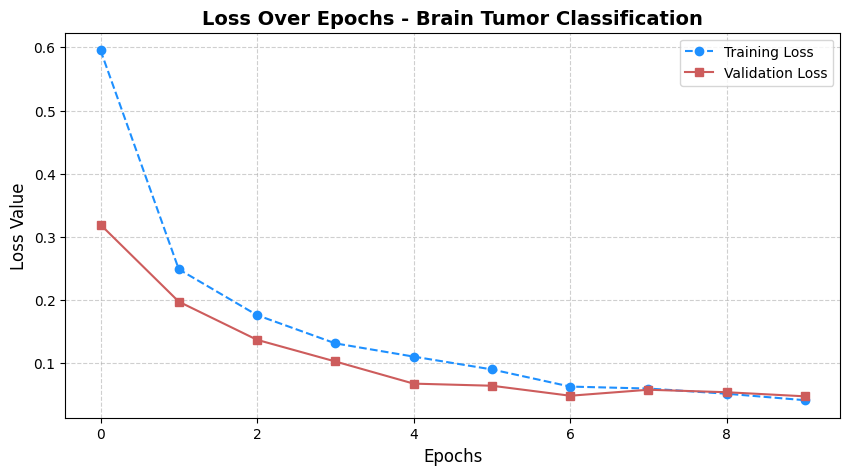

In [13]:
# ----------------------------------------------------------------------------
# Visualizing Training & Validation Loss Over Epochs
# ----------------------------------------------------------------------------

# Creating a new figure for the loss plot
plt.figure(figsize = (10, 5))

# Plotting the training loss over epochs with markers and dashed line
plt.plot(train_loss_history, label = 'Training Loss', linestyle = '--',
         marker = 'o', color = 'dodgerblue')

# Plotting the validation loss over epochs with markers and solid line
plt.plot(valid_loss_history, label = 'Validation Loss', linestyle = '-',
         marker = 's', color = 'indianred')

# Setting the plot title with bold styling
plt.title('Loss Over Epochs - Brain Tumor Classification', fontsize = 14, fontweight = 'bold')

# Labeling the x-axis as "Epochs"
plt.xlabel('Epochs', fontsize = 12)

# Labeling the y-axis as "Loss Value"
plt.ylabel('Loss Value', fontsize = 12)

# Displaying the legend to differentiate Training & Validation Loss
plt.legend()

# Adding a grid with dashed lines and slight transparency
plt.grid(True, linestyle = '--', alpha = 0.6)

# Displaying the loss plot
plt.show()


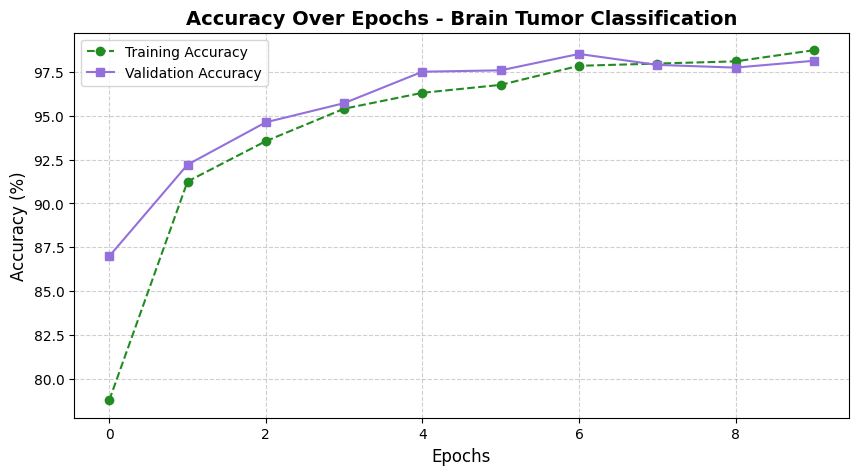

In [14]:
# ----------------------------------------------------------------------------
# Visualizing Training & Validation Accuracy Over Epochs
# ----------------------------------------------------------------------------

# Creating a new figure for the accuracy plot
plt.figure(figsize = (10, 5))

# Plotting the training accuracy over epochs with markers and dashed line
plt.plot(train_acc_history, label = 'Training Accuracy', linestyle = '--',
         marker = 'o', color = 'forestgreen')

# Plotting the validation accuracy over epochs with markers and solid line
plt.plot(valid_acc_history, label = 'Validation Accuracy', linestyle = '-',
         marker = 's', color = 'mediumpurple')

# Setting the plot title with bold styling
plt.title('Accuracy Over Epochs - Brain Tumor Classification', fontsize = 14, fontweight = 'bold')

# Labeling the x-axis as "Epochs"
plt.xlabel('Epochs', fontsize = 12)

# Labeling the y-axis as "Accuracy (%)"
plt.ylabel('Accuracy (%)', fontsize = 12)

# Displaying the legend to differentiate Training & Validation Accuracy
plt.legend()

# Adding a grid with dashed lines and slight transparency
plt.grid(True, linestyle = '--', alpha = 0.6)

# Displaying the accuracy plot
plt.show()


## Analyzing Misclassifications and Confusion Matrix

In [15]:
# ----------------------------------------------------------------------------
# Evaluating the Model and Computing the Confusion Matrix
# ----------------------------------------------------------------------------

# Setting the model to evaluation mode (disables dropout & batch norm updates)
brain_mri_model.eval()

# Initializing lists to store actual labels and predicted labels
true_labels = []
predicted_labels = []

# Disabling gradient calculations to improve inference efficiency
with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        # Moving batch features and labels to the appropriate computation device (CPU/GPU)
        batch_features, batch_labels = batch_features.to(hardware_device), batch_labels.to(hardware_device)

        # Making predictions using the trained model
        outputs = brain_mri_model(batch_features)

        # Selecting the class with the highest probability
        _, preds = torch.max(outputs, 1)

        # Storing true labels and predicted labels as NumPy arrays
        true_labels.extend(batch_labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())

# Computing the confusion matrix to evaluate classification performance
conf_matrix = confusion_matrix(true_labels, predicted_labels)


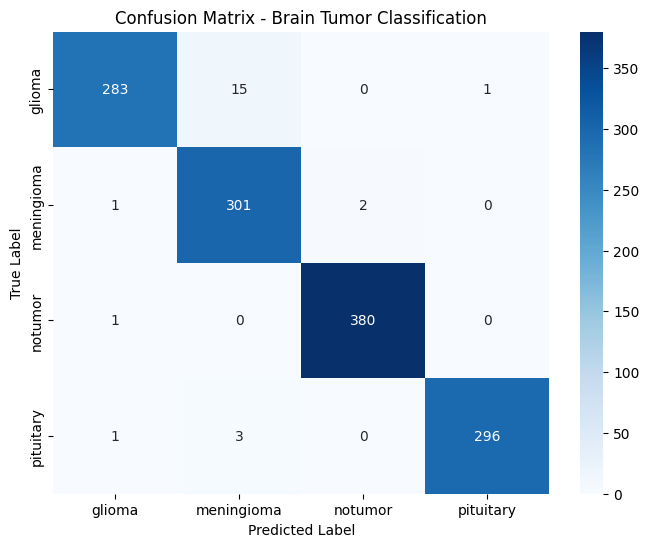

In [16]:
# ----------------------------------------------------------------------------
# Visualizing the Confusion Matrix
# ----------------------------------------------------------------------------

# Creating a figure for the confusion matrix plot
plt.figure(figsize=(8, 6))

# Plotting the confusion matrix as a heatmap
sns.heatmap(conf_matrix,
            annot=True,        # Displaying numerical values in each cell
            fmt='d',           # Formatting numbers as integers
            cmap="Blues",      # Using a blue color map for better visualization
            xticklabels=tumor_labels,  # Labeling x-axis with tumor class names
            yticklabels=tumor_labels)  # Labeling y-axis with tumor class names

# Labeling axes and adding a title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Brain Tumor Classification")

# Displaying the confusion matrix
plt.show()


In [17]:
# ----------------------------------------------------------------------------
# Generating and Displaying the Classification Report
# ----------------------------------------------------------------------------

# Printing a header for better readability
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=tumor_labels))


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.95      0.97       299
  meningioma       0.94      0.99      0.97       304
     notumor       0.99      1.00      1.00       381
   pituitary       1.00      0.99      0.99       300

    accuracy                           0.98      1284
   macro avg       0.98      0.98      0.98      1284
weighted avg       0.98      0.98      0.98      1284



## Explore Decision Making Influence through LIME & Grad-CAM visualizations

Next steps:


*   Selecting images to visualize
*   Load and preprocess the images
*   Computing LIME and Grad-CAM
*   Overlaying heatmap on images
*   Plotting results




In [18]:
# ----------------------------------------------------------------------------
# Defining Function for Collecting Image Paths for Each Tumor Class
# ----------------------------------------------------------------------------

def get_image_paths(folder):
    """
    Collecting and organizing image file paths from a dataset directory.

    Parameters
    ----------
    folder : str
        Path to the dataset directory (e.g., Training or Testing folder).

    Returns
    -------
    image_paths : dict
        Dictionary where keys are tumor class names, and values are lists of image file paths.
    """

    image_paths = {}  # Initializing dictionary to store class-wise image paths

    for tumor_class in os.listdir(folder):
        class_path = os.path.join(folder, tumor_class)  # Constructing full class directory path

        if os.path.isdir(class_path):  # Ensuring the entry is a directory (not a file)
            class_name = tumor_class.lower().replace(" ", "_")  # Normalizing class names (converting to lowercase, replacing spaces with underscores)

            # Retrieving all image file paths for this class and storing them in a list
            image_paths[class_name] = [os.path.join(class_path, img) for img in os.listdir(class_path)]

    return image_paths  # Returning the dictionary containing image paths for each class


# ----------------------------------------------------------------------------
# Retrieving Image Paths for Training & Testing Datasets
# ----------------------------------------------------------------------------

# Extracting image paths for the Training dataset
train_image_paths = get_image_paths(os.path.join(dataset_path, "Training"))

# Extracting image paths for the Testing dataset
test_image_paths = get_image_paths(os.path.join(dataset_path, "Testing"))


# ----------------------------------------------------------------------------
# Displaying the Number of Images Available for Each Tumor Class
# ----------------------------------------------------------------------------

print("Displaying the number of images available in the Testing dataset:")
for tumor_class, images in test_image_paths.items():
    print(f"{tumor_class}: {len(images)} images available")  # Displaying the count of images per class


# ----------------------------------------------------------------------------
# Verifying Image Paths and Handling Missing Files
# ----------------------------------------------------------------------------

for tumor_class, images in test_image_paths.items():
    for idx, img_path in enumerate(images):

        # Ensuring we do not access an out-of-bounds index
        if idx >= len(images):
            break  # Exiting loop safely

        # Checking if the image file exists before processing
        if not os.path.exists(img_path):
            print(f"Warning: Missing file detected - {img_path}")
            continue  # Skipping processing for missing files

        # Placeholder for adding further processing logic (e.g., loading, preprocessing, inference, etc.)
        print(f"Processing {tumor_class}: {img_path}")


Displaying the number of images available in the Testing dataset:
glioma: 299 images available
notumor: 381 images available
pituitary: 300 images available
meningioma: 304 images available
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0023.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0239.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0283.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0058.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0212.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0249.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0097.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0179.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0197.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0288.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0161.jpg
Processing glioma: brain_tumor_data/Testing/glioma/Te-gl_0214.jpg
Processing glioma:

In [19]:
# ----------------------------------------------------------------------------
# Checking Dataset Labels & Extracting Image Paths for Classification Analysis
# ----------------------------------------------------------------------------

# Displaying the tumor labels and available test dataset categories
print("Tumor Labels:", tumor_labels)  # Prints all class labels
print("Keys in test_image_paths:", test_image_paths.keys())  # Prints available test categories

# ----------------------------------------------------------------------------
# Initializing Data Structures for Image Path Tracking
# ----------------------------------------------------------------------------

# Dictionary to store image paths for correctly and incorrectly classified images
selected_images = {
    "correct": {},  # Storing correctly classified images per class
    "incorrect": {}  # Storing misclassified images per class
}

# Dictionary to track indices per class to prevent out-of-bounds errors
class_indices = {label: 0 for label in test_image_paths.keys()}

# ----------------------------------------------------------------------------
# Iterating Through Test Samples & Comparing Predictions
# ----------------------------------------------------------------------------

for i, (true_label, pred_label) in enumerate(zip(true_labels, predicted_labels)):

    # Converting class labels to lowercase and replacing spaces for consistency
    true_class = tumor_labels[true_label].lower().replace(" ", "_")
    pred_class = tumor_labels[pred_label].lower().replace(" ", "_")

    # Handling Missing Classes in `test_image_paths`
    if true_class not in test_image_paths:
        print(f"Warning: '{true_class}' not found in test_image_paths.")
        continue  # Skip this iteration to prevent KeyError

    # Retrieving the next available index for the current class
    class_idx = class_indices[true_class]

    # Making sure the class index does not exceed the available image count
    if class_idx >= len(test_image_paths[true_class]):
        print(f"Warning: Index {class_idx} out of bounds for class '{true_class}'.")
        continue  # Skip this iteration to prevent out-of-bounds error

    # Retrieving the image path from the dataset
    image_path = test_image_paths[true_class][class_idx]

    # Incrementing the index tracker for this class
    class_indices[true_class] += 1

    # ----------------------------------------------------------------------------
    # Storing Correctly Classified and Misclassified Images Separately
    # ----------------------------------------------------------------------------

    if true_label == pred_label:
        # Storing correctly classified image if not already stored
        if true_class not in selected_images["correct"]:
            selected_images["correct"][true_class] = image_path
    else:
        # Storing misclassified image if not already stored
        if true_class not in selected_images["incorrect"]:
            selected_images["incorrect"][true_class] = {
                "image_path": image_path,
                "predicted_label": pred_class
            }

# ----------------------------------------------------------------------------
# Displaying Summary of Correct & Misclassified Examples
# ----------------------------------------------------------------------------

print("\nCorrectly Classified Examples:")
for tumor_type, path in selected_images["correct"].items():
    print(f"{tumor_type.capitalize()}: {path}")

print("\nMisclassified Examples:")
for tumor_type, details in selected_images["incorrect"].items():
    print(f"{tumor_type.capitalize()} misclassified as {details['predicted_label'].capitalize()}: {details['image_path']}")


Tumor Labels: ['glioma', 'meningioma', 'notumor', 'pituitary']
Keys in test_image_paths: dict_keys(['glioma', 'notumor', 'pituitary', 'meningioma'])

Correctly Classified Examples:
Glioma: brain_tumor_data/Testing/glioma/Te-gl_0023.jpg
Meningioma: brain_tumor_data/Testing/meningioma/Te-me_0114.jpg
Notumor: brain_tumor_data/Testing/notumor/Te-no_0021.jpg
Pituitary: brain_tumor_data/Testing/pituitary/Te-pi_0176.jpg

Misclassified Examples:
Glioma misclassified as Meningioma: brain_tumor_data/Testing/glioma/Te-gl_0259.jpg
Meningioma misclassified as Notumor: brain_tumor_data/Testing/meningioma/Te-me_0181.jpg
Notumor misclassified as Glioma: brain_tumor_data/Testing/notumor/Te-no_0296.jpg
Pituitary misclassified as Meningioma: brain_tumor_data/Testing/pituitary/Te-pi_0171.jpg


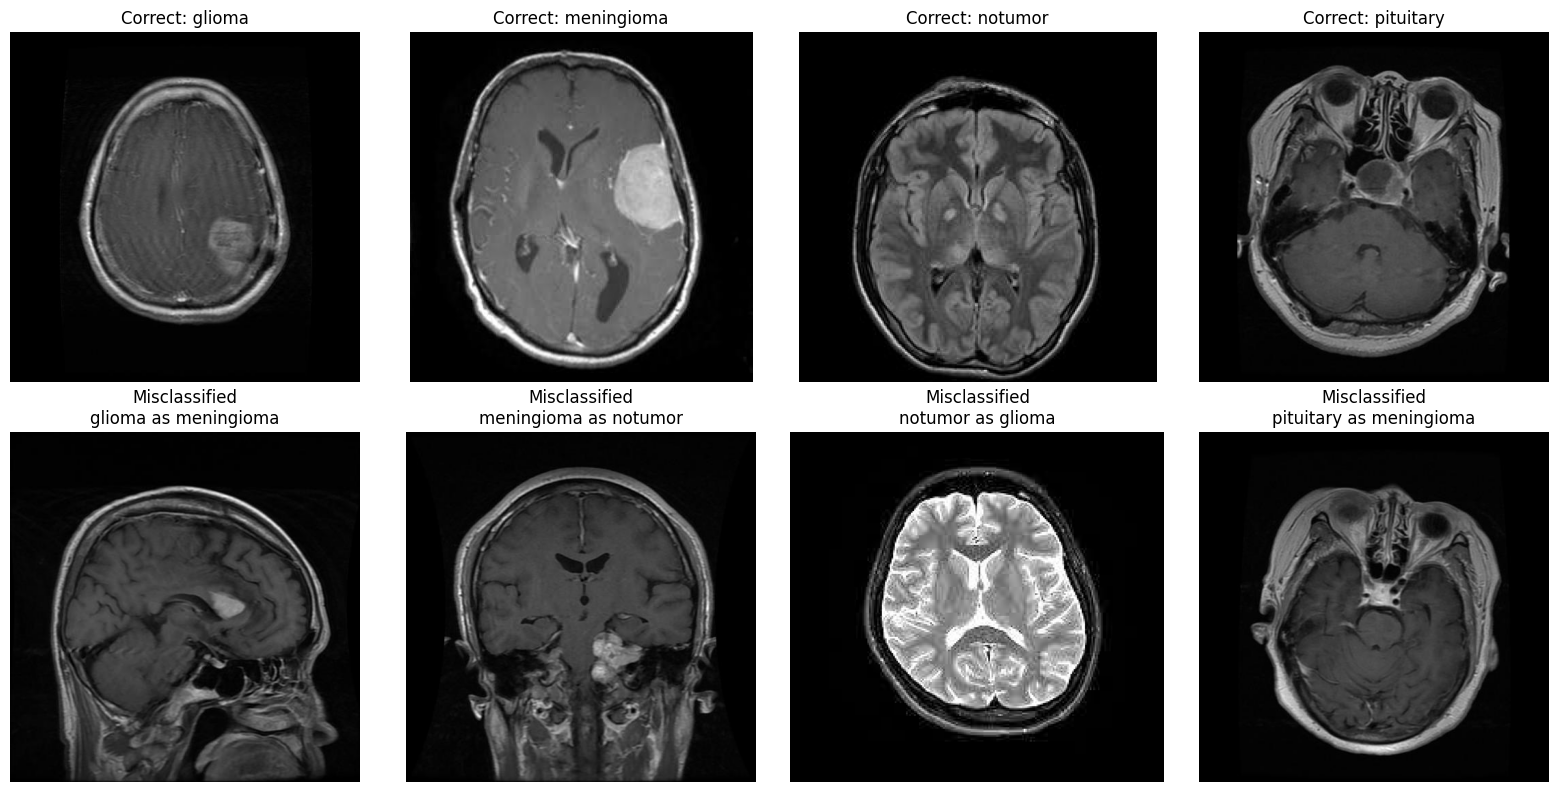

In [20]:
# ----------------------------------------------------------------------------
# Defining Function for Displaying Correctly and Incorrectly Classified Images
# ----------------------------------------------------------------------------

def display_classification_results(selected_images):
    """
    Displaying correctly and incorrectly classified brain MRI images.

    Parameters
    ----------
    selected_images : dict
        A dictionary containing correctly and incorrectly classified images.
        - "correct" : {tumor_type: image_path}
        - "incorrect" : {tumor_type: {"image_path": path, "predicted_label": label}}

    Returns
    -------
    None
    """

    # Counting the number of correctly and incorrectly classified images
    num_correct = len(selected_images["correct"])
    num_incorrect = len(selected_images["incorrect"])

    # Determining the maximum number of columns needed for visualization
    num_cols = max(num_correct, num_incorrect)

    # Creating a figure with 2 rows (correct & incorrect classifications) and dynamic columns
    fig, axes = plt.subplots(2, num_cols, figsize = (num_cols * 4, 8))

    # Ensuring axes is always a 2D array, even if only one column is present
    if num_cols == 1:
        axes = axes.reshape(2, 1)

    # ----------------------------------------------------------------------------
    # Displaying Correctly Classified Images
    # ----------------------------------------------------------------------------

    for idx, (tumor_type, image_path) in enumerate(selected_images["correct"].items()):
        img = cv2.imread(image_path)  # Loading the image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converting BGR to RGB for correct visualization

        axes[0, idx].imshow(img)  # Displaying the image
        axes[0, idx].set_title(f"Correct: {tumor_type}", fontsize = 12)  # Adding title with tumor type
        axes[0, idx].axis("off")  # Hiding axis ticks and labels

    # ----------------------------------------------------------------------------
    # Displaying Incorrectly Classified Images
    # ----------------------------------------------------------------------------

    for idx, (tumor_type, details) in enumerate(selected_images["incorrect"].items()):
        img = cv2.imread(details["image_path"])  # Loading the image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converting BGR to RGB

        axes[1, idx].imshow(img)  # Displaying the image
        axes[1, idx].set_title(f"Misclassified\n{tumor_type} as {details['predicted_label']}", fontsize = 12)
        axes[1, idx].axis("off")  # Hiding axis ticks and labels

    # ----------------------------------------------------------------------------
    # Hiding Unused Subplots
    # ----------------------------------------------------------------------------

    for idx in range(num_correct, num_cols):  # Hiding any extra subplots in the correct row
        axes[0, idx].axis("off")

    for idx in range(num_incorrect, num_cols):  # Hiding any extra subplots in the incorrect row
        axes[1, idx].axis("off")

    # ----------------------------------------------------------------------------
    # Adding Labels for Rows
    # ----------------------------------------------------------------------------

    axes[0, 0].set_ylabel("Correctly Classified", fontsize = 14, fontweight = "bold")
    axes[1, 0].set_ylabel("Misclassified", fontsize = 14, fontweight = "bold")

    # Adjusting layout for better visualization
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
# Running the Visualization Function
# ----------------------------------------------------------------------------

display_classification_results(selected_images)


## USING LIME Explanation

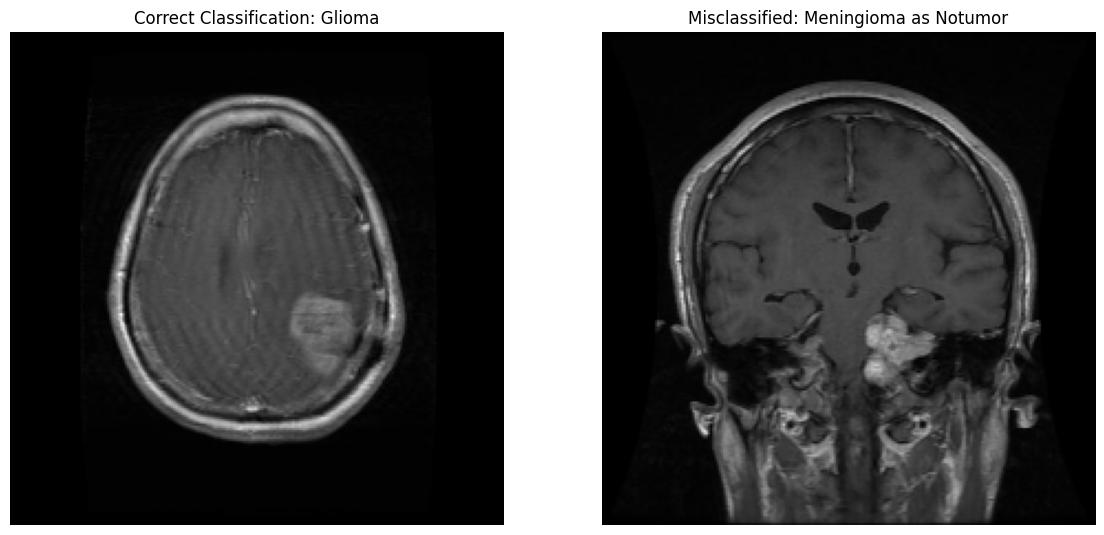

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

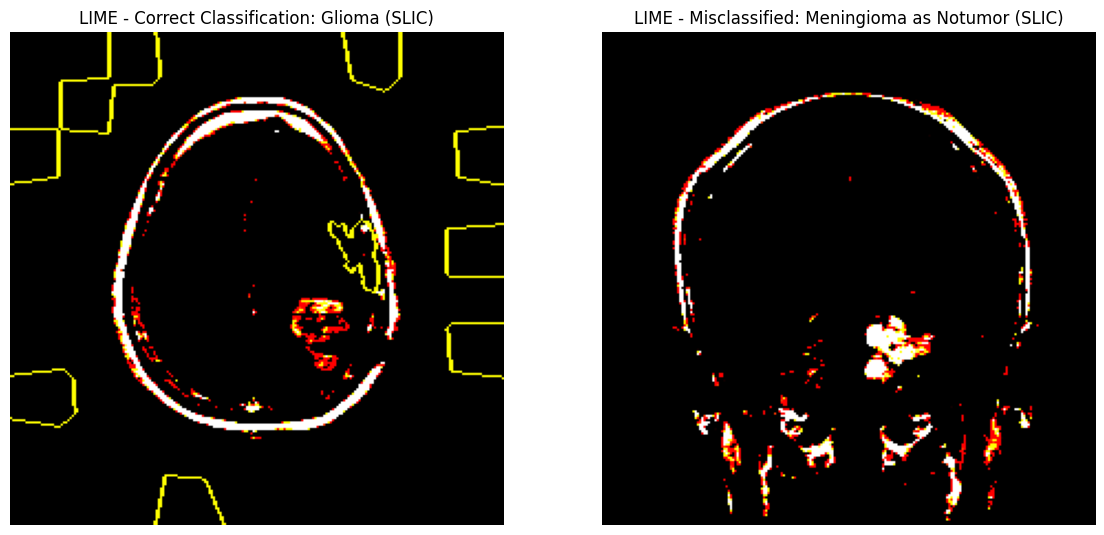

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

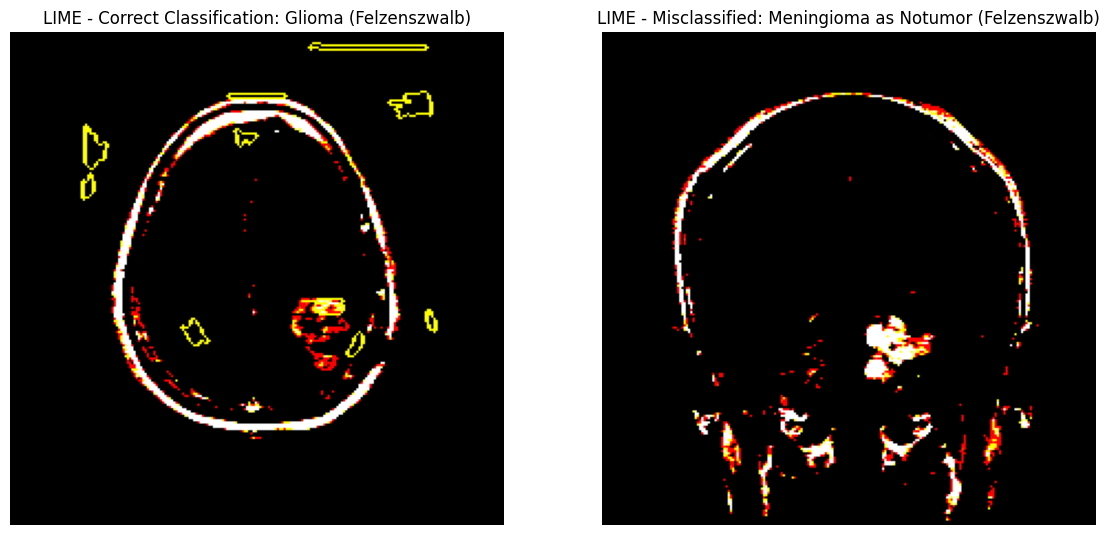

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

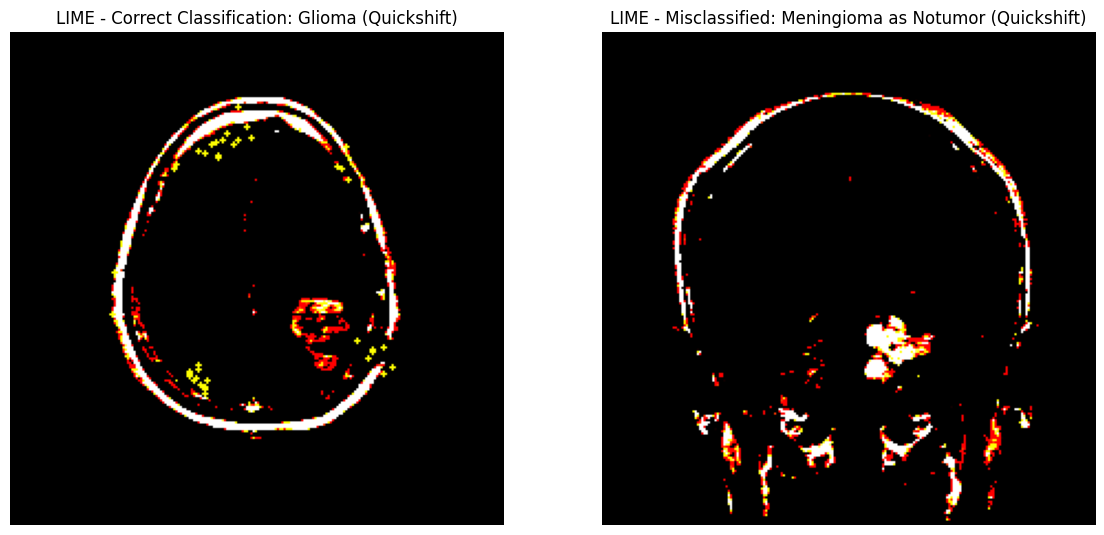

In [21]:
# =============================================================================
# Fixing Clipping (Denormalization)
# =============================================================================

def denormalize_image(img):
    """
    Convert ResNet preprocessed image back to [0,255] RGB range.

    Parameters
    ----------
    img : numpy.ndarray
        Input image that has been preprocessed for ResNet.

    Returns
    -------
    numpy.ndarray
        Denormalized image converted back to integer format.
    """
    mean = np.array([123.68, 116.779, 103.939])  # ImageNet mean values
    img = img + mean  # Add back the mean
    img = np.clip(img, 0, 255)  # Ensure values are within valid range
    return img.astype(np.uint8)  # Convert to uint8 format


# =============================================================================
# Loading & Preprocessing Images
# =============================================================================

def load_and_preprocess(image_path):
    """
    Loading an image and preprocessing it for ResNet50 model.

    Parameters
    ----------
    image_path : str
        Path to the image file.

    Returns
    -------
    tuple
        The original image (RGB format) and preprocessed image (normalized for ResNet).
    """
    img = cv2.imread(image_path)  # Reading image from disk
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converting BGR to RGB format
    img = cv2.resize(img, (224, 224))  # Resizing for ResNet50 input dimensions
    processed_img = preprocess_input(img.astype(np.float32))  # Normalizing using ResNet50 preprocessing
    return img, processed_img  # Returning both original and preprocessed versions


# =============================================================================
# Selecting Images for LIME Analysis
# =============================================================================

# Selecting a correctly classified tumor image
correct_label = list(selected_images["correct"].keys())[0]  # Getting first correct classification
correct_image_path = selected_images["correct"][correct_label]  # Retrieving image path

# Selecting an incorrectly classified tumor misclassified as "notumor"
incorrect_label, incorrect_data = None, None

for tumor_type, details in selected_images["incorrect"].items():
    if details["predicted_label"] == "notumor":  # Making sure it was misclassified as "notumor"
        incorrect_label = tumor_type  # Storing actual tumor type
        incorrect_data = details  # Storing image details
        break  # Stopping search once a case is found

# Handling case where no tumors were misclassified as "notumor"
if incorrect_data is None:
    print("No misclassified tumors as 'notumor' found. Using any incorrect case instead.")
    incorrect_label, incorrect_data = list(selected_images["incorrect"].items())[0]

incorrect_image_path = incorrect_data["image_path"]  # Retrieving incorrect image path
incorrect_predicted_label = incorrect_data["predicted_label"]  # Retrieving misclassification label

# Loading both selected images
original_correct, sample_correct = load_and_preprocess(correct_image_path)
original_incorrect, sample_incorrect = load_and_preprocess(incorrect_image_path)


# =============================================================================
# Displaying Original Images (Before LIME)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Correctly Classified Image (Before LIME)
axes[0].imshow(original_correct)
axes[0].set_title(f"Correct Classification: {correct_label.capitalize()}")
axes[0].axis("off")

# Incorrectly Classified Image (Before LIME)
axes[1].imshow(original_incorrect)
axes[1].set_title(f"Misclassified: {incorrect_label.capitalize()} as {incorrect_predicted_label.capitalize()}")
axes[1].axis("off")

plt.show()


# =============================================================================
# Defining Prediction Function for LIME
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available

def model_predict(images):
    """
    Generating model predictions for LIME interpretation.

    Parameters
    ----------
    images : list
        Listing preprocessed images as NumPy arrays.

    Returns
    -------
    numpy.ndarray
        Predicted probability scores for each class.
    """
    images = np.array(images)  # Converting list to NumPy array
    images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)  # Converting to tensor with correct shape
    images = images.to(device)  # Moving to GPU if available

    with torch.no_grad():  # Disabling gradient calculations for inference
        preds = brain_mri_model(images)  # Getting model predictions
        preds = torch.softmax(preds, dim=1)  # Converting logits to probabilities

    return preds.cpu().numpy()  # Converting back to NumPy format


# =============================================================================
# Defining Segmentation Methods
# =============================================================================

segmentation_methods = {
    "SLIC"        : slic,
    "Felzenszwalb": felzenszwalb,
    "Quickshift"  : quickshift
}


# =============================================================================
# Creating LIME Explainer
# =============================================================================

explainer = LimeImageExplainer()


# =============================================================================
# Running LIME for Each Segmentation Method
# =============================================================================

for seg_name, segmentation_fn in segmentation_methods.items():

    # Running LIME for the correctly classified image
    explanation_correct = explainer.explain_instance(
        sample_correct,
        model_predict,
        top_labels = 2,
        hide_color = 0,
        num_samples = 1000,
        segmentation_fn = segmentation_fn
    )

    # Running LIME for the incorrectly classified image
    explanation_incorrect = explainer.explain_instance(
        sample_incorrect,
        model_predict,
        top_labels = 2,
        hide_color = 0,
        num_samples = 1000,
        segmentation_fn = segmentation_fn
    )

    # =============================================================================
    # Extracting Highlighted Regions from LIME
    # =============================================================================

    # Extracting LIME's highlighted regions for correct classification
    temp_correct, mask_correct = explanation_correct.get_image_and_mask(
        label = explanation_correct.top_labels[0],
        positive_only = True,
        num_features = 10,
        hide_rest = False
    )

    # Extracting LIME's highlighted regions for incorrect classification
    temp_incorrect, mask_incorrect = explanation_incorrect.get_image_and_mask(
        label = explanation_incorrect.top_labels[0],
        positive_only = True,
        num_features = 10,
        hide_rest = False
    )

    # =============================================================================
    # Displaying Results Side-by-Side
    # =============================================================================

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Correctly Classified Image (LIME)
    axes[0].imshow(mark_boundaries(temp_correct, mask_correct))
    axes[0].set_title(f"LIME - Correct Classification: {correct_label.capitalize()} ({seg_name})")
    axes[0].axis("off")

    # Incorrectly Classified Image (LIME)
    axes[1].imshow(mark_boundaries(temp_incorrect, mask_incorrect))
    axes[1].set_title(f"LIME - Misclassified: {incorrect_label.capitalize()} as {incorrect_predicted_label.capitalize()} ({seg_name})")
    axes[1].axis("off")

    plt.show()


Running Grad-CAM for ConvLayer_1...


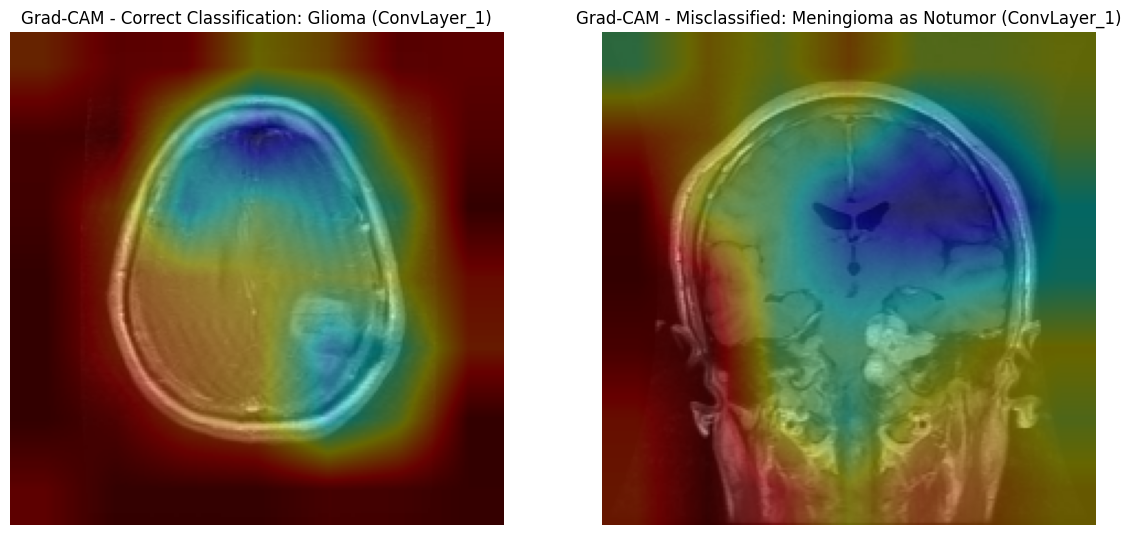

Running Grad-CAM for ConvLayer_2...


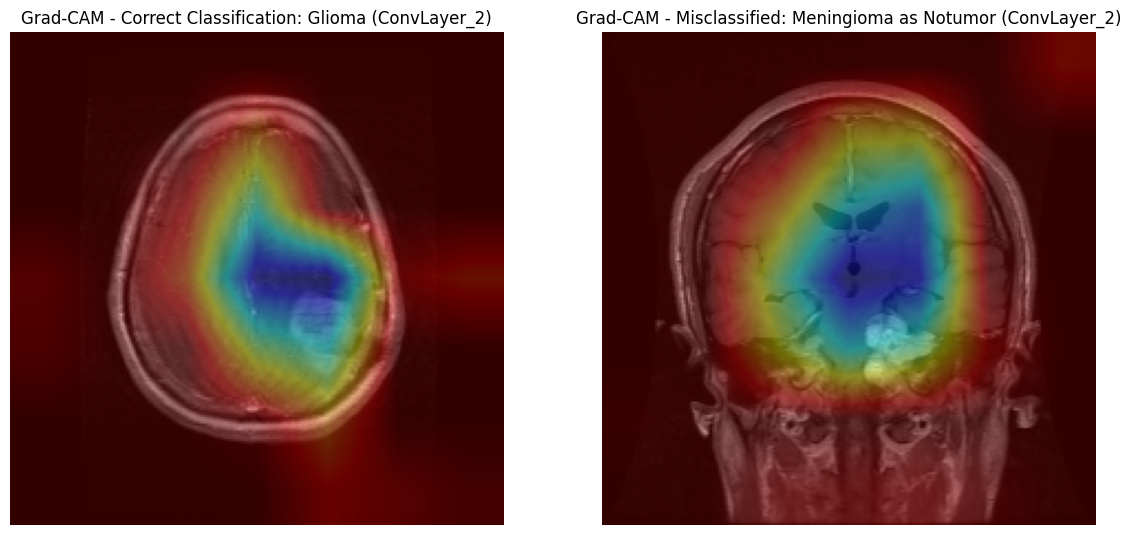

Running Grad-CAM for ConvLayer_3...


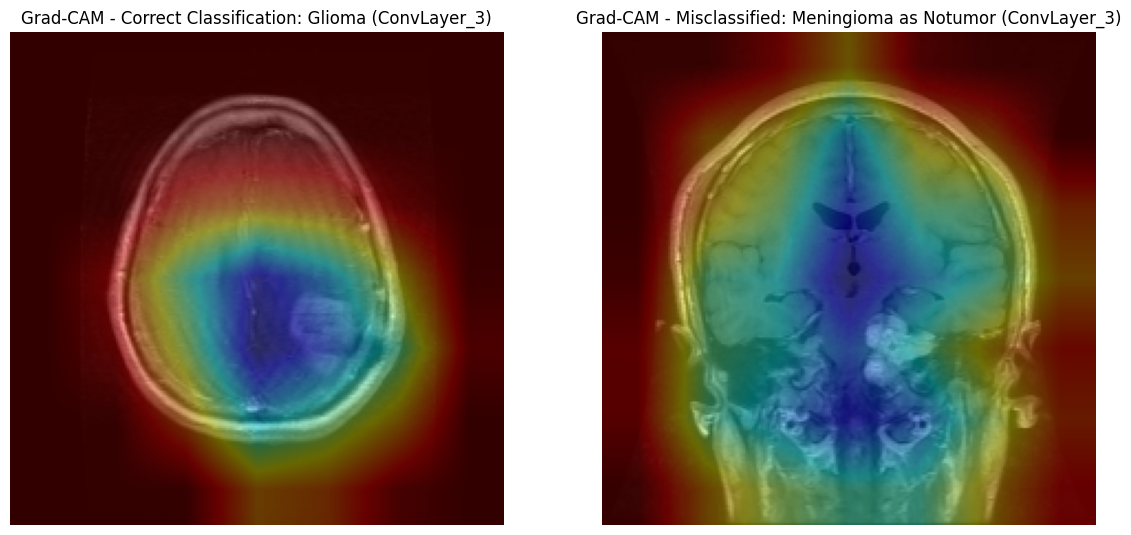

In [22]:
# =============================================================================
# Setting Device for Computation
# =============================================================================

# Assigning the appropriate device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Moving the trained model to the selected device and setting it to evaluation mode
brain_mri_model = brain_mri_model.to(device).eval()


# =============================================================================
# Loading & Preprocessing Images
# =============================================================================

def load_and_preprocess(image_path):
    """
    Loading an MRI image and preprocess it for model input.

    Parameters
    ----------
    image_path : str
        Path to the image file.

    Returns
    -------
    tuple
        Original image (RGB format) and preprocessed image (tensor normalized to [0,1]).
    """
    img = cv2.imread(image_path)  # Reading image from file
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converting BGR to RGB format
    img = cv2.resize(img, (224, 224))  # Resizing to match model input requirements
    processed_img = img.astype(np.float32) / 255.0  # Normalizing pixel values to [0,1]
    processed_img = torch.tensor(processed_img).permute(2, 0, 1).unsqueeze(0)  # Reshaping to (1,3,224,224)
    return img, processed_img.to(device)  # Returning both original and processed versions


# =============================================================================
# Selecting Images for Grad-CAM Analysis
# =============================================================================

# Selecting a correctly classified tumor image
correct_label = list(selected_images["correct"].keys())[0]  # Retrieving the first correct classification
correct_image_path = selected_images["correct"][correct_label]  # Retrieving the corresponding image path

# Selecting an incorrectly classified tumor misclassified as "notumor"
incorrect_label, incorrect_data = None, None

for tumor_type, details in selected_images["incorrect"].items():
    if details["predicted_label"] == "notumor":  # Making sure it was misclassified as "notumor"
        incorrect_label = tumor_type  # Storing the actual tumor type
        incorrect_data = details  # Storing the image details
        break  # Stopping once a case is found

# Handling the case where no tumors were misclassified as "notumor"
if incorrect_data is None:
    print("No misclassified tumors as 'notumor' found. Using any incorrect case instead.")
    incorrect_label, incorrect_data = list(selected_images["incorrect"].items())[0]

# Retrieving paths for the selected images
incorrect_image_path = incorrect_data["image_path"]
incorrect_predicted_label = incorrect_data["predicted_label"]

# Loading both selected images
original_correct, sample_correct = load_and_preprocess(correct_image_path)
original_incorrect, sample_incorrect = load_and_preprocess(incorrect_image_path)


# =============================================================================
# Implementing Grad-CAM Class
# =============================================================================

class GradCam:
    """
    Class for computing Grad-CAM heatmaps for a given model layer.

    Attributes
    ----------
    model : torch.nn.Module
        The trained model.
    target_layer : torch.nn.Module
        The convolutional layer for which Grad-CAM is applied.

    Methods
    -------
    forward_hook_fn(module, input, output)
        Stores the activations from the target layer during forward pass.
    backward_hook_fn(module, grad_input, grad_output)
        Stores the gradients from the target layer during backward pass.
    generate_heatmap(input_tensor, class_idx)
        Computes and returns a Grad-CAM heatmap for the given image.
    remove_hooks()
        Removes registered hooks after processing.
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register forward hook to capture activations
        self.forward_hook = target_layer.register_forward_hook(self.forward_hook_fn)
        # Register backward hook to capture gradients
        self.backward_hook = target_layer.register_full_backward_hook(self.backward_hook_fn)

    def forward_hook_fn(self, module, input, output):
        """Captures activations from the forward pass."""
        self.activations = output

    def backward_hook_fn(self, module, grad_input, grad_output):
        """Captures gradients from the backward pass."""
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx):
        """
        Generate Grad-CAM heatmap for a specific class.

        Parameters
        ----------
        input_tensor : torch.Tensor
            Preprocessed input image tensor.
        class_idx : int
            Target class index.

        Returns
        -------
        numpy.ndarray
            Generated heatmap for visualization.
        """
        output = self.model(input_tensor)  # Forward pass
        score = output[0, class_idx]  # Extracting score for the target class
        self.model.zero_grad()
        score.backward(retain_graph=True)  # Backpropagating to compute gradients

        # Computing weight coefficients
        alpha = self.gradients.mean(dim=(2, 3), keepdim=True)
        heatmap = (alpha * self.activations).sum(dim=1, keepdim=True)
        heatmap = F.relu(heatmap)  # Applying ReLU to remove negative influences

        # Normalizing the heatmap
        heatmap = heatmap.squeeze().detach().cpu().numpy()
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

        return heatmap

    def remove_hooks(self):
        """Removes hooks after processing each layer to avoid conflicts."""
        self.forward_hook.remove()
        self.backward_hook.remove()


# =============================================================================
# Overlaying Heatmaps on Original Images
# =============================================================================

def overlay_heatmap(original_image, heatmap):
    """
    Overlay a Grad-CAM heatmap onto the original image.

    Parameters
    ----------
    original_image : numpy.ndarray
        The original RGB image.
    heatmap : numpy.ndarray
        The generated Grad-CAM heatmap.

    Returns
    -------
    numpy.ndarray
        The image with the heatmap overlay.
    """
    heatmap = cv2.resize(heatmap, (224, 224))  # Resizing to match image dimensions
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)  # Applying color mapping
    superimposed_img = cv2.addWeighted(original_image, 0.6, heatmap, 0.4, 0)  # Blending the heatmap with the image
    return superimposed_img


# =============================================================================
# Running Grad-CAM for Each Selected Layer
# =============================================================================

# Defining target layers for Grad-CAM analysis
target_layers = {
    "ConvLayer_1": brain_mri_model.layer4[0].conv2,
    "ConvLayer_2": brain_mri_model.layer4[1].conv2,
    "ConvLayer_3": brain_mri_model.layer4[2].conv2,
}

# Iterating through selected layers and computing Grad-CAM
for layer_name, target_layer in target_layers.items():
    print(f"Running Grad-CAM for {layer_name}...")

    grad_cam = GradCam(brain_mri_model, target_layer)  # Creating Grad-CAM instance

    # Generating predictions
    correct_pred = brain_mri_model(sample_correct).argmax().item()
    incorrect_pred = brain_mri_model(sample_incorrect).argmax().item()

    # Computing Grad-CAM heatmaps
    heatmap_correct = grad_cam.generate_heatmap(sample_correct, correct_pred)
    heatmap_incorrect = grad_cam.generate_heatmap(sample_incorrect, incorrect_pred)

    # Overlaying heatmaps
    overlay_correct = overlay_heatmap(original_correct, heatmap_correct)
    overlay_incorrect = overlay_heatmap(original_incorrect, heatmap_incorrect)

    grad_cam.remove_hooks()  # Removing hooks before the next iteration

    # Displaying results
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(overlay_correct)
    axes[0].set_title(f"Grad-CAM - Correct Classification: {correct_label.capitalize()} ({layer_name})")
    axes[0].axis("off")

    axes[1].imshow(overlay_incorrect)
    axes[1].set_title(f"Grad-CAM - Misclassified: {incorrect_label.capitalize()} as {incorrect_predicted_label.capitalize()} ({layer_name})")
    axes[1].axis("off")

    plt.show()
